In [1]:
import tensorflow as tf
import numpy as np
import os
import re
import matplotlib.pyplot as plt

# Function to read and parse the tensor data from a text file
def parse_tensor_from_file(file_path, shape):
    with open(file_path, 'r') as file:
        # Read the content of the file
        tensor_str = file.read()

    components = re.findall(r"([+-]?\d+\.?\d*[eE]?[+-]?\d*(?:\s*[+-]?\d*\.?\d*[eE]?[+-]?\d*j)?)", tensor_str)
    # Convert the components into a numpy array of complex numbers
    complex_numbers = [complex(c.replace(' ','')) for c in components]

    # Convert the list to a NumPy array and reshape it
    numpy_tensor = np.array(complex_numbers, dtype=np.complex128)

    if (shape == 3):
        numpy_tensor = numpy_tensor.reshape(round(numpy_tensor.size ** (1/shape)),round(numpy_tensor.size ** (1/shape)),round(numpy_tensor.size ** (1/shape)))
    if (shape == 2):
        size = numpy_tensor.size
        new_shape = (round(size ** (1/shape)), round(size ** (1/shape))) if shape == 2 else (size,)
        numpy_tensor = numpy_tensor.reshape(new_shape)
    # Convert NumPy array to TensorFlow tensor
    tf_tensor = tf.convert_to_tensor(numpy_tensor)

    return tf_tensor

def retrieve_dict(base_dir, filename, reverse = False):
    # Dictionary to hold costs organized by prefix (i)
    fidelity_dict = {}
    
    # Iterate through each subfolder in the base directory
    folder_names = os.listdir(base_dir)
    
    # Sort folders numerically or lexicographically
    folder_names.sort(key=lambda x: int(x.split('_')[0]))

    # Iterate through each subfolder in the base directory
    for folder_name in folder_names:
        folder_path = os.path.join(base_dir, folder_name)
        if os.path.isdir(folder_path):
            # Extract the prefix for identifying the 'i' value
            prefix = folder_name.split('_')[0]
            # Path to the cost.txt file
            cost_file_path = os.path.join(folder_path, filename)
            
            # Read the cost value from the cost.txt file
            if os.path.exists(cost_file_path):
                    # Extract the complex number part using regular expression
                    tensor = parse_tensor_from_file(cost_file_path, 1)
                    # Convert the extracted string to a complex number
                    for t in tensor.numpy():
                         # Get the real part and convert to float
                         float_value = t.real
                         if (reverse == True):
                             float_value = 1 - t.real
                         # if (float_value < 10e-4): continue
                         if prefix not in fidelity_dict:
                              fidelity_dict[prefix] = []
                         fidelity_dict[prefix].append(abs(float_value))
    
    return fidelity_dict


def merge_dicts(dict_list, labels):
    """
    Merges multiple dictionaries into one, with new keys labeled by the given labels.

    Parameters:
        dict_list (list of dict): List of dictionaries to merge.
        labels (list of str): Labels for each dictionary.

    Returns:
        dict: Merged dictionary with new keys.
    """
    merged_dict = {}
    for i, (d, label) in enumerate(zip(dict_list, labels)):
        for key, values in d.items():
            new_key = f"{label}"
            if new_key not in merged_dict:
               merged_dict[new_key] = []
            for v in values:
                merged_dict[new_key].append(v)
    return merged_dict

2025-06-20 13:11:00.065046: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-06-20 13:11:00.118991: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1750392660.176193 3030047 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1750392660.184823 3030047 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1750392660.226017 3030047 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

{'tm': [np.float64(23.422584295272827), np.float64(162.75226497650146), np.float64(1218.1332869529724), np.float64(10521.827909469604), np.float64(124087.11523103714)], 'ts': [np.float64(10.104851245880127), np.float64(33.62878227233887), np.float64(89.26423120498657), np.float64(292.8290419578552), np.float64(1192.8105249404907)]}


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


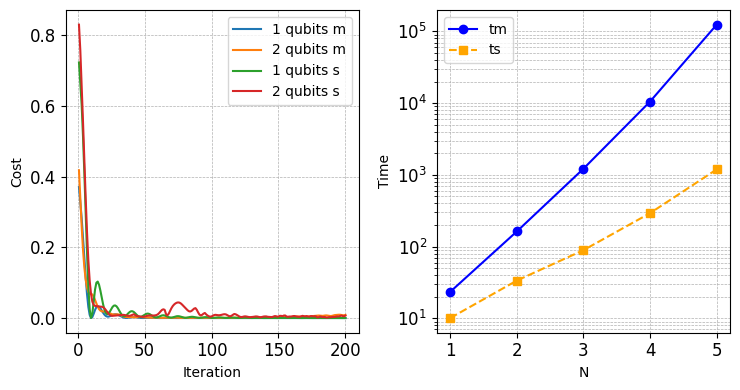

In [4]:
def plot_dict(fidelity_dict, xlabel, ylabel, file_name, max_val, step):
    # Plotting
    for i, (key, values) in enumerate(fidelity_dict.items()):
        plt.plot(values, label=f"{key}")
    plt.xlabel(xlabel, fontsize=16)
    plt.ylabel(ylabel, fontsize=16)
    #plt.yscale('log')  # Set y-axis to logarithmic scale
    x_ticks = np.arange(0, max_val, step=step)
    plt.xticks(ticks=x_ticks, fontsize=13)
    plt.yticks(fontsize=13)
    plt.grid(True)
    plt.legend(fontsize=13, ncol=2)

def plot_fidelity(qubits, data, xlabel, ylabel, file_name):
    # Scatter Plot
    for label, values in data.items():
        marker = 's' if 'Our' in label else 'o'
        color = 'blue' if 'Our' in label else 'red'
        plt.scatter(qubits, values, marker=marker, color=color, label=label, facecolors='none')
        plt.plot(qubits, values, color=color, linestyle='-', linewidth=1)  
    plt.xlabel(xlabel, fontsize=16)
    plt.ylabel(ylabel, fontsize=16)
    plt.yscale('log')  # Set y-axis to logarithmic scale
    x_ticks = np.arange(qubits[0], qubits[-1]+1, step=1)
    plt.xticks(ticks=x_ticks, fontsize=13)
    plt.yticks(fontsize=13)
    plt.grid(True)
    plt.legend(fontsize=13)
def combined_plot(fidelity_dict, qubits, fidelity_data, xlabel_a, ylabel_a, xlabel_b, ylabel_b, file_name, max_val, step):
    # Create the figure with two subplots
    fig, axs = plt.subplots(2, 1, figsize=(7, 8.5))  # Adjust the size of the figure

    # Plot for the first subplot (a)
    plt.sca(axs[0])  # Select the first subplot
    plot_dict(fidelity_dict, xlabel_a, ylabel_a, file_name, max_val, step)
    plt.text(0.98, 0.15, 'a)', transform=axs[0].transAxes, fontsize=16, verticalalignment='top', horizontalalignment='right')

    # Plot for the second subplot (b)
    plt.sca(axs[1])  # Select the second subplot
    plot_fidelity(qubits, fidelity_data, xlabel_b, ylabel_b, file_name)
    plt.text(0.98, 0.15, 'b)', transform=axs[1].transAxes, fontsize=16, verticalalignment='top', horizontalalignment='right')
    
    plt.subplots_adjust(hspace=0.3)

    # Save the combined plot as both PNG and EPS
    # plt.savefig('../../docs/new_fig/'+file_name+'.png', format='png', bbox_inches='tight')
    # plt.savefig('../../docs/new_fig/'+file_name+'.eps', format='eps', bbox_inches='tight')

    # Display the plot
    plt.show()

import matplotlib.pyplot as plt

def plot_cost_and_time(n, tm, ts, cost_dict_m, cost_dict_s, file_name, x_cost=None):
    if x_cost is None:
        x_cost = list(range(1, 201))

    fig, axs = plt.subplots(1, 2, figsize=(7.5, 4))

    # Time plot (right)
    axs[1].plot(n, tm, marker='o', linestyle='-', color='blue', label='tm')
    axs[1].plot(n, ts, marker='s', linestyle='--', color='orange', label='ts')
    axs[1].set_xlabel('N')
    axs[1].set_ylabel('Time')
    axs[1].set_yscale('log')
    axs[1].legend()
    axs[1].grid(True, which='both', linestyle='--', linewidth=0.5)
    axs[1].tick_params(axis='both', labelsize=12)

    # Cost evolution plot (left)
    for qubit, values in cost_dict_m.items():
        axs[0].plot(x_cost, values, label=f'{qubit} qubits m')
    for qubit, values in cost_dict_s.items():
        axs[0].plot(x_cost, values, label=f'{qubit} qubits s')

    axs[0].set_xlabel('Iteration')
    axs[0].set_ylabel('Cost')
    axs[0].legend()
    axs[0].grid(True, which='both', linestyle='--', linewidth=0.5)
    axs[0].tick_params(axis='both', labelsize=12)

    plt.tight_layout()
    plt.savefig('../../docs/new_fig/'+file_name+'.png')
    plt.savefig('../../docs/new_fig/'+file_name+'.eps')
    plt.show()
    


#plt.rc('font', family='serif')
folder_path = '../../results/experiment_new/comparison_temp'

#Get final fidelity dict
dict_m = retrieve_dict(folder_path, 'time.txt', True)
dict_s = retrieve_dict(folder_path, 'time_ours.txt', True)
merged = merge_dicts([dict_m, dict_s], ["tm", "ts"])
qubits = [1, 2, 3, 4, 5]
print(merged)
#Get final cost dict
cost_dict_m = retrieve_dict(folder_path, 'cost_dict.txt')
cost_dict_m = dict(list(cost_dict_m.items())[:2])
cost_dict_s = retrieve_dict(folder_path, 'cost_dict_ours.txt')
cost_dict_s = dict(list(cost_dict_s.items())[:2])
plot_cost_and_time(qubits, merged['tm'], merged['ts'], cost_dict_m, cost_dict_s, "fig7", x_cost=None)
